# Travel Recommendations by Political Label & Token Score

Given a portrait ("This is a photo of me") the VLM recommends US travel destinations.
Compare LEAN_DEM vs LEAN_REP recommendations, and visualize by `all_mean` token score bins.

In [2]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [3]:
RESPONSES_PATH = Path("/project/jevans/tzhang3/dotty-project/linear-political-llm/results/prompt_generation/qwen3_vl/easyportrait_1000samples_max512tok_features_travel_responses.jsonl")

records = []
with open(RESPONSES_PATH) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

successful = [r for r in records if r.get("_travel_response")]
print(f"Loaded {len(records)} responses ({len(successful)} successful)")
df = pd.DataFrame(records)
print(df["extracted_label"].value_counts().to_string())

Loaded 100 responses (100 successful)
extracted_label
LEAN_DEM    50
LEAN_REP    50


In [4]:
# Parse locations: each entry is {city, state, matched_name}
# Cities already have their state resolved from geonamescache
def parse_locations(records):
    lib_states, lib_cities = Counter(), Counter()
    con_states, con_cities = Counter(), Counter()
    for r in records:
        label = r.get("extracted_label", "")
        locs = r.get("_locations", [])
        for loc in locs:
            state = loc.get("state", "")
            city = loc.get("city", "")
            if not city:
                continue
            city_state = f"{city}, {state}" if state else city
            if "LEAN_DEM" in label:
                lib_states[state] += 1
                lib_cities[city_state] += 1
            else:
                con_states[state] += 1
                con_cities[city_state] += 1
    return lib_states, lib_cities, con_states, con_cities

lib_states, lib_cities, con_states, con_cities = parse_locations(successful)

all_states = lib_states + con_states
all_cities = lib_cities + con_cities
print(f"  Unique states: {len(all_states)}  |  Unique cities: {len(all_cities)}")

  Unique states: 18  |  Unique cities: 27


## Top Destination States by Political Label

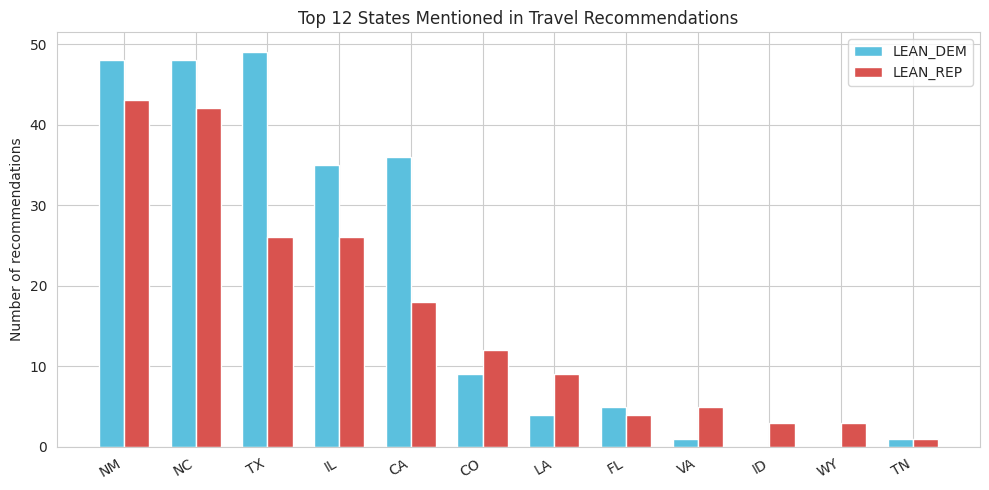

In [5]:
top_n = 12
top_states = all_states.most_common(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
names = [s for s, _ in top_states]
x = np.arange(len(names))
width = 0.35

lib_vals = [lib_states.get(n, 0) for n in names]
con_vals = [con_states.get(n, 0) for n in names]

ax.bar(x - width/2, lib_vals, width, label="LEAN_DEM", color="#5bc0de")
ax.bar(x + width/2, con_vals, width, label="LEAN_REP", color="#d9534f")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Number of recommendations")
ax.set_title(f"Top {top_n} States Mentioned in Travel Recommendations")
ax.legend()
plt.tight_layout()
plt.show()

## Top Destination Cities by Political Label

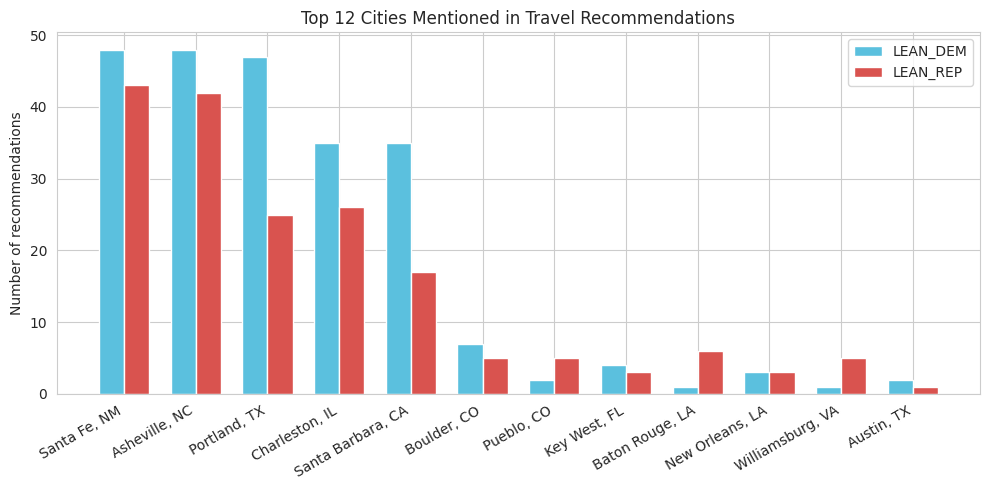

In [6]:
top_cities = all_cities.most_common(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
names = [s for s, _ in top_cities]
x = np.arange(len(names))

lib_vals = [lib_cities.get(n, 0) for n in names]
con_vals = [con_cities.get(n, 0) for n in names]

ax.bar(x - width/2, lib_vals, width, label="LEAN_DEM", color="#5bc0de")
ax.bar(x + width/2, con_vals, width, label="LEAN_REP", color="#d9534f")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Number of recommendations")
ax.set_title(f"Top {top_n} Cities Mentioned in Travel Recommendations")
ax.legend()
plt.tight_layout()
plt.show()

## Difference: LEAN_DEM − LEAN_REP Mentions

Positive = more Dem; negative = more Rep

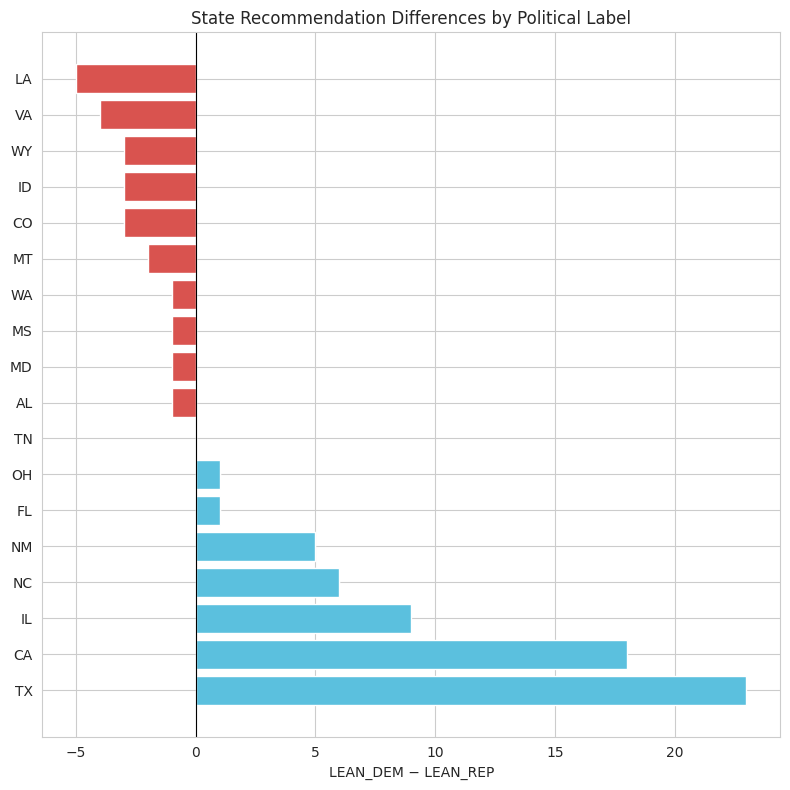

In [7]:
# State-level difference
all_state_names = sorted(set(list(lib_states.keys()) + list(con_states.keys())))
diffs = [(n, lib_states.get(n, 0) - con_states.get(n, 0)) for n in all_state_names]
diffs.sort(key=lambda x: x[1], reverse=True)

top_diff = diffs[:15]
bottom_diff = diffs[-15:]
all_diff = top_diff + bottom_diff

fig, ax = plt.subplots(figsize=(8, 8))
names = [d[0] for d in all_diff]
vals = [d[1] for d in all_diff]
colors = ["#5bc0de" if v > 0 else "#d9534f" for v in vals]

ax.barh(names, vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("LEAN_DEM − LEAN_REP")
ax.set_title("State Recommendation Differences by Political Label")
plt.tight_layout()
plt.show()

## Recommendations by `all_mean` Token Score Bins

Split successful responses into 3 equal-width bins of `all_mean` (the mean token score from the linear probe).
Higher `all_mean` → more conservative-associated tokens.

In [8]:
# Filter to records with valid all_mean and successful response
scored = [r for r in successful if r.get("all_mean") is not None]
scores = [r["all_mean"] for r in scored]

print(f"Records with all_mean: {len(scored)}")
print(f"all_mean range: [{min(scores):.4f}, {max(scores):.4f}]")
print(f"all_mean mean:  {np.mean(scores):.4f}")

Records with all_mean: 100
all_mean range: [-0.1333, 0.5983]
all_mean mean:  0.2850


In [9]:
n_bins = 3
bins = np.linspace(min(scores), max(scores), n_bins + 1)
bin_labels = [f"Low ({bins[0]:.3f} – {bins[1]:.3f})",
              f"Mid ({bins[1]:.3f} – {bins[2]:.3f})",
              f"High ({bins[2]:.3f} – {bins[3]:.3f})"]

# Bin records
binned_records = {i: [] for i in range(n_bins)}
for r in scored:
    for i in range(n_bins):
        if bins[i] <= r["all_mean"] <= bins[i+1] or (i == n_bins - 1 and r["all_mean"] >= bins[i]):
            binned_records[i].append(r)
            break

for i in range(n_bins):
    print(f"  {bin_labels[i]}: {len(binned_records[i])} records")

  Low (-0.133 – 0.111): 18 records
  Mid (0.111 – 0.354): 41 records
  High (0.354 – 0.598): 41 records


In [10]:
# Compute city and state counters per bin
bin_states = {}
bin_cities = {}
for i in range(n_bins):
    # build fresh counters for this bin
    bs, bc = Counter(), Counter()
    for r in binned_records[i]:
        for loc in r.get("_locations", []):
            state = loc.get("state", "")
            city = loc.get("city", "")
            if city:
                bs[state] += 1
                city_state = f"{city}, {state}" if state else city
                bc[city_state] += 1
    bin_states[i] = bs
    bin_cities[i] = bc

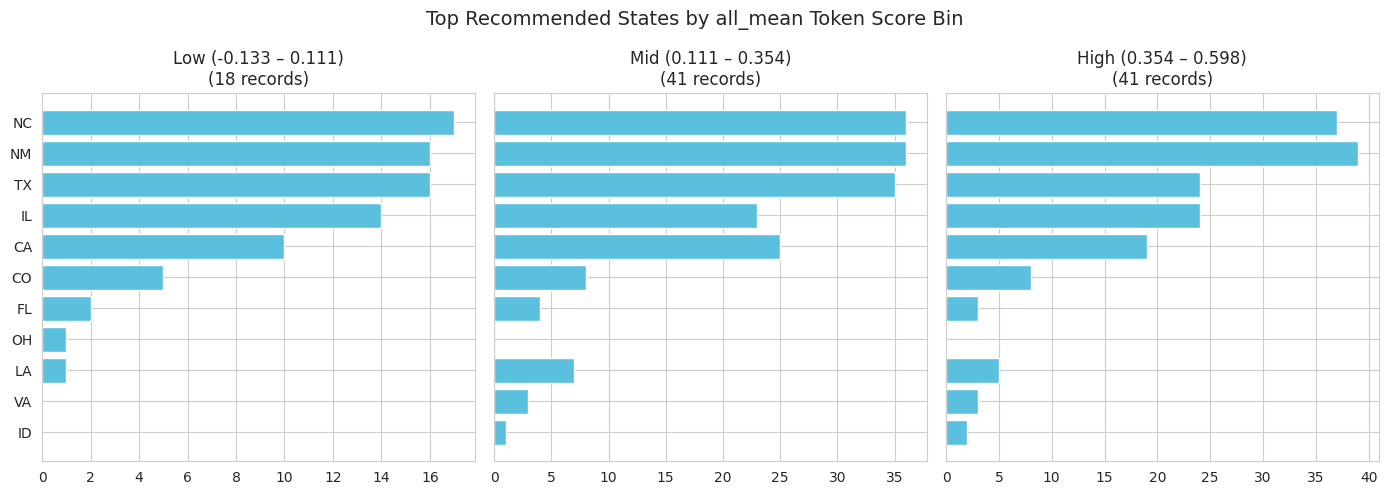

In [11]:
# Plot top states per bin as side-by-side bar charts
fig, axes = plt.subplots(1, n_bins, figsize=(14, 5), sharey=True)

for i in range(n_bins):
    ax = axes[i]
    top = bin_states[i].most_common(10)
    if not top:
        ax.set_title(f"{bin_labels[i]}\n(no data)")
        continue
    names = [t[0] for t in top]
    vals = [t[1] for t in top]
    ax.barh(names, vals, color="#5bc0de")
    ax.set_title(f"{bin_labels[i]}\n({len(binned_records[i])} records)")
    ax.invert_yaxis()

fig.suptitle("Top Recommended States by all_mean Token Score Bin", fontsize=14)
plt.tight_layout()
plt.show()

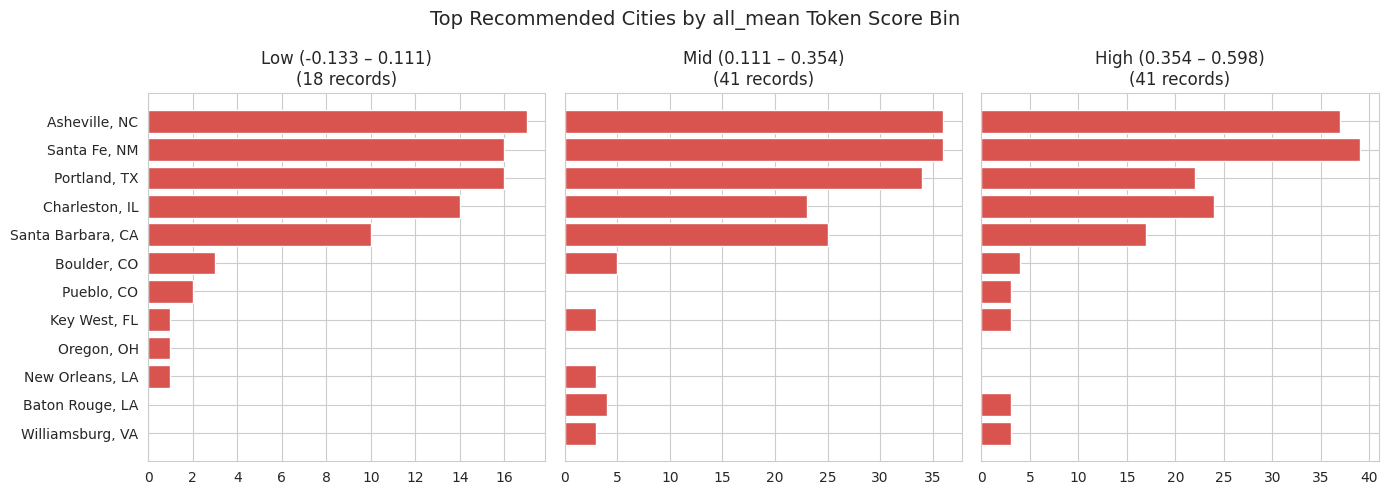

In [12]:
# Plot top cities per bin as side-by-side bar charts
fig, axes = plt.subplots(1, n_bins, figsize=(14, 5), sharey=True)

for i in range(n_bins):
    ax = axes[i]
    top = bin_cities[i].most_common(10)
    if not top:
        ax.set_title(f"{bin_labels[i]}\n(no data)")
        continue
    names = [t[0] for t in top]
    vals = [t[1] for t in top]
    ax.barh(names, vals, color="#d9534f")
    ax.set_title(f"{bin_labels[i]}\n({len(binned_records[i])} records)")
    ax.invert_yaxis()

fig.suptitle("Top Recommended Cities by all_mean Token Score Bin", fontsize=14)
plt.tight_layout()
plt.show()

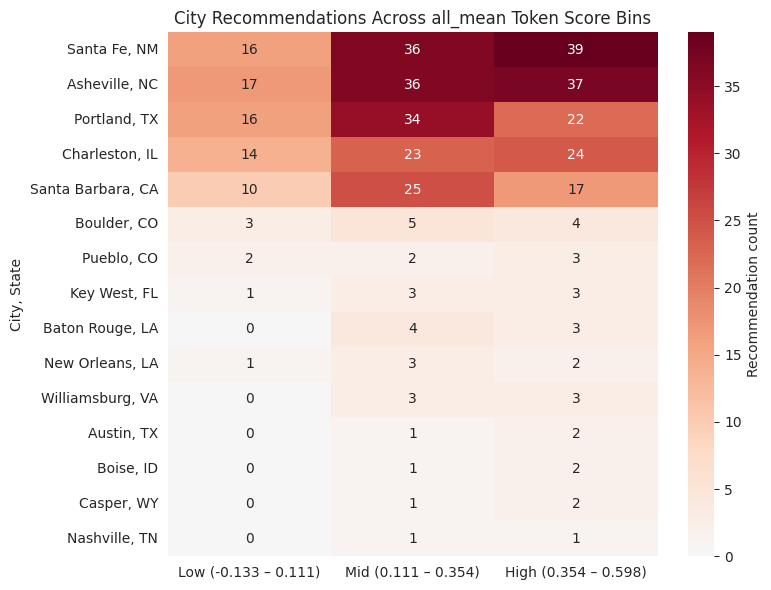

In [13]:
# Heatmap: how city recommendations shift across bins
top_overall_cities = all_cities.most_common(15)
heatmap_data = {}
for city_name, _ in top_overall_cities:
    heatmap_data[city_name] = [bin_cities[i].get(city_name, 0) for i in range(n_bins)]

hm_df = pd.DataFrame(heatmap_data, index=bin_labels).T

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hm_df, annot=True, fmt="d", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Recommendation count"})
ax.set_title("City Recommendations Across all_mean Token Score Bins")
ax.set_ylabel("City, State")
plt.tight_layout()
plt.show()